In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter('error')

from matplotlib.gridspec import GridSpec
from sklearn.linear_model import LinearRegression
from scipy.stats import sem, pearsonr
from scipy.ndimage import gaussian_filter1d

# Parameters for Minecraft task
calibration_onsets = [1, 494]
calibration_points = [24, 12]
interval = 1.6 


In [4]:
import mocet

task = 'task-mcHERDING'
subject_pool = {
                'sub-003':{'ses-07R':([1,2,3,4,5], False),
                           'ses-13R':([1,2,4,5,6], False)},
                'sub-004':{'ses-07R':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-005':{'ses-07':([1,2,3,4,5,6], True)},
                'sub-006':{'ses-07R':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-008':{'ses-07R':([2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-009':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,5,6], False)},
                'sub-010':{'ses-07':([1,2,3,4,5], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-011':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-012':{'ses-07':([1,2,4,5,6], False)},
                'sub-013':{'ses-07':([1,2,3,4], False)},
                'sub-014':{'ses-07':([2,3,4,5,6], False)},
                'sub-015':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-016':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-017':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5], False)},
                'sub-018':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-020':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-021':{'ses-07':([1,2,4,5,6], False),
                           'ses-13':([1,2,4,5,6], False)},
                'sub-JJY':{'ses-07':([1,2,3,4,5,6], False)},
                'sub-KMY':{'ses-07':([1,2,3,4,5,6], False)},
                'sub-PJW':{'ses-07':([1,2,3,4,6], True)},
                'sub-PBJ':{'ses-07':([1,2,3,4,5], False)}
                }

task_duration = 816
history_onset = {'sub-005': [28.66, 29.32, 28.12, 33.7, 36.1, 27.46],
                 'sub-PJW': [35, 30.8, 28.66, 26.58, None, 27.42]}

do_mocet = False
calibration_offset_start = 0.55
calibration_offset_end = -0.55
pupil_valid_threshold = 0.2
pupil_confidence_threshold = 0.8
calibration_threshold = 1.0
px_per_deg = 78.43
avg_pupil_diameter_mm = 5

group_subjects = []
group_calibration_errors = []
group_validation_errors = []
testable_data = {}
subjects = subject_pool.keys()
method = 'linear'
for subject in subjects:
    subject_calibration_errors = []
    subject_validation_errors = []
    
    sessions = subject_pool[subject].keys()
    for session in sessions:
        runs, history_loss = subject_pool[subject][session]
        root = f'../_DATA/{subject}/{session}'
        for r in runs:
            np.random.seed(0) # for reproducibility
            
            run = f'run-{r}'
            print(subject, session, task, run)
            
            log_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_log.csv'
            data_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_dat.txt'
            confounds_fname = f'{root}/{subject}_{session}_{task}_{run}_desc-confounds_timeseries.tsv'
            
            if history_loss: 
                start = history_onset[subject][r-1]
            else:
                history_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_his.txt'
                start, _, _ = mocet.utils.get_avotec_history(history_fname)
                
            # log, data, confound, start
            pupil_data, pupil_timestamps, pupil_confidence, pupil_diameter = mocet.utils.clean_avotec_data(log_fname,
                                                                                                    data_fname,
                                                                                                    start=start,
                                                                                                    duration=task_duration)
            pupil_validity = np.sum(np.isnan(pupil_confidence))/len(pupil_confidence)
            mean_pupil_confidence = np.nanmean(pupil_confidence)
            mean_pupil_diameter = np.nanmean(pupil_diameter)
            pupil_diameter_mm_per_px = avg_pupil_diameter_mm / mean_pupil_diameter
            print(f"Eye closed: {pupil_validity:2.2f}, Avg. confidence: {mean_pupil_confidence:2.2f}, Avg. diameter: {mean_pupil_diameter:2.2f}")
   
            if pupil_timestamps[-1] > 815000:
                
                calibration_errors = []
                calibration_n_valid_points = []
                for t in range(len(calibration_points)):
                    offset = calibration_onsets[t]
                    calibration_pupils = []
                    for i in np.arange(calibration_points[t]):
                        start = (offset+i)*interval + calibration_offset_start
                        end = (offset+i+1)*interval + calibration_offset_end
                        log_effective = np.logical_and(pupil_timestamps >= start*1000, pupil_timestamps < end*1000)
                        calibration_pupils.append([np.nanmean(pupil_data[log_effective,0]),
                                                  np.nanmean(pupil_data[log_effective,1])])
                    calibration_pupils = np.array(calibration_pupils)
                    
                    repeat = True if calibration_points[t]==24 else False
                    calibrator = mocet.EyetrackingCalibration(repeat=repeat, method=method)
                    calibrator.fit(calibration_pupils[:, 0], calibration_pupils[:, 1])
                    gaze_coordinates = calibrator.transform(pupil_data)
        
                    # Test accuracy
                    MSE = []
                    calibration_confidence = []
                    for i in np.arange(calibration_points[t]):
                        ref_x, ref_y = calibrator.reference(i)
                        start = (offset+i)*interval + calibration_offset_start
                        end = (offset+i+1)*interval + calibration_offset_end
                        gaze_idx_start = np.min(np.where(pupil_timestamps >= start*1000)[0])
                        gaze_idx_end = np.min(np.where(pupil_timestamps >= end*1000)[0])
                        eye_closed = np.isnan(pupil_confidence[gaze_idx_start:gaze_idx_end])
                        calibration_confidence += list(pupil_confidence[gaze_idx_start:gaze_idx_end])
                        if np.any(~eye_closed):
                            data_x = np.nanmean(gaze_coordinates[gaze_idx_start:gaze_idx_end,0][~eye_closed])
                            data_y = np.nanmean(gaze_coordinates[gaze_idx_start:gaze_idx_end,1][~eye_closed])
                            MSE.append(np.sqrt((ref_x-data_x)**2 + (ref_y-data_y)**2))
                    mean_calibration_confidence = np.nanmean(calibration_confidence)
                    if len(MSE) >= 12 and mean_calibration_confidence > pupil_confidence_threshold:
                        calibration_errors.append(np.nanmean(MSE)/px_per_deg)
                        calibration_n_valid_points.append(len(MSE))
                    else:
                        calibration_errors.append(10e5)
                        calibration_n_valid_points.append(0)
                
                # determine validation trial
                t_cal, t_val = 0, 1
                flag = False
                print(calibration_errors[t_cal], calibration_errors[t_val])
                if calibration_errors[t_cal] < calibration_threshold and calibration_errors[t_val] < calibration_threshold:
                    flag = True
                else:
                    pass
                    #print(subject, session, task, run, calibration_errors[t_cal], calibration_errors[t_val])
                    
                if flag: #Testable run
                    key = (subject, session, task, run)
                        
                    calibration_pupils = []
                    offset = calibration_onsets[t_cal]
                    for i in np.arange(calibration_points[t_cal]):
                        start = (offset+i)*interval + calibration_offset_start
                        end = (offset+i+1)*interval + calibration_offset_end
                        log_effective = np.logical_and(pupil_timestamps >= start*1000, pupil_timestamps < end*1000)
                        calibration_pupils.append([np.nanmean(pupil_data[log_effective,0]),
                                                  np.nanmean(pupil_data[log_effective,1])])
                    calibration_pupils = np.array(calibration_pupils)
                    calibration_center = np.mean(calibration_pupils, axis=0)
                    
                    repeat = True if calibration_points[t_cal]==24 else False
                    calibrator = mocet.EyetrackingCalibration(repeat=repeat, method=method)
                    calibrator.fit(calibration_pupils[:, 0], calibration_pupils[:, 1])
                    gaze_coordinates = calibrator.transform(pupil_data)
        
            
                    MSE = []
                    offset = calibration_onsets[t_val]
                    validation_pupils = []
                    for i in np.arange(calibration_points[t_val]):
                        ref_x, ref_y = calibrator.reference(i)
                        start = (offset+i)*interval + calibration_offset_start
                        end = (offset+i+1)*interval + calibration_offset_end
                        log_effective = np.logical_and(pupil_timestamps >= start*1000, pupil_timestamps < end*1000)
                        validation_pupils.append([np.nanmean(pupil_data[log_effective,0]),
                                                  np.nanmean(pupil_data[log_effective,1])])
                    
                        gaze_idx_start = np.min(np.where(pupil_timestamps >= start*1000)[0])
                        gaze_idx_end = np.min(np.where(pupil_timestamps >= end*1000)[0])
                        eye_closed = np.isnan(pupil_confidence[gaze_idx_start:gaze_idx_end])
                        if np.any(~eye_closed):
                            data_x = np.nanmean(gaze_coordinates[gaze_idx_start:gaze_idx_end,0][~eye_closed])
                            data_y = np.nanmean(gaze_coordinates[gaze_idx_start:gaze_idx_end,1][~eye_closed])
                            MSE.append(np.sqrt((ref_x-data_x)**2 + (ref_y-data_y)**2))
                    if len(MSE) > 0:
                        validation_error = np.nanmean(MSE)/px_per_deg
                        validation_center = np.mean(validation_pupils, axis=0)
                    else:
                        validation_error = np.nan
                        validation_center = np.nan * np.ones(2)
                    calibration_error = calibration_errors[t_cal]
        
                    subject_calibration_errors.append(calibration_error)
                    subject_validation_errors.append(validation_error)
                    pupil_displacement = np.linalg.norm(calibration_center - validation_center) * pupil_diameter_mm_per_px
                    pupil_displacement_x = (calibration_center[0] - validation_center[0]) * pupil_diameter_mm_per_px
                    pupil_displacement_y = (calibration_center[1] - validation_center[1]) * pupil_diameter_mm_per_px
                    testable_data[key] = (t_cal, calibration_error, t_val, validation_error, 
                                          pupil_displacement, pupil_displacement_x, pupil_displacement_y)
                    
    if len(subject_calibration_errors)>0 and len(subject_validation_errors)>0:
        group_subjects.append(subject)
        group_calibration_errors.append(np.nanmean(subject_calibration_errors))
        group_validation_errors.append(np.nanmean(subject_validation_errors))
    
print(np.mean(group_calibration_errors), np.mean(group_validation_errors))

save_testable_data = False
if save_testable_data:
    import pickle
    with open('testable_data_list.pkl', 'wb') as f:
        pickle.dump(testable_data, f)

sub-003 ses-07R task-mcHERDING run-1
Eye closed: 0.07, Avg. confidence: 0.99, Avg. diameter: 91.91
0.439710165181016 0.6664401199561253
sub-003 ses-07R task-mcHERDING run-2
Eye closed: 0.10, Avg. confidence: 0.99, Avg. diameter: 96.15
0.40259067363988416 0.3520359314465243
sub-003 ses-07R task-mcHERDING run-3
Eye closed: 0.07, Avg. confidence: 0.99, Avg. diameter: 95.50
0.4362591657172323 0.5444020317406012
sub-003 ses-07R task-mcHERDING run-4
Eye closed: 0.08, Avg. confidence: 0.99, Avg. diameter: 92.76
0.2725680855681849 1.0689747319802652
sub-003 ses-07R task-mcHERDING run-5
Eye closed: 0.63, Avg. confidence: 0.99, Avg. diameter: 93.82
sub-003 ses-13R task-mcHERDING run-1
Eye closed: 0.06, Avg. confidence: 0.99, Avg. diameter: 77.87
0.7538288440740041 0.20469001961179717
sub-003 ses-13R task-mcHERDING run-2
Eye closed: 0.18, Avg. confidence: 0.99, Avg. diameter: 83.32
0.6756096619222569 0.6799953473091707
sub-003 ses-13R task-mcHERDING run-4
Eye closed: 0.08, Avg. confidence: 0.99, 

TtestResult(statistic=-8.43628411290673, pvalue=7.549025443038577e-08, df=19)


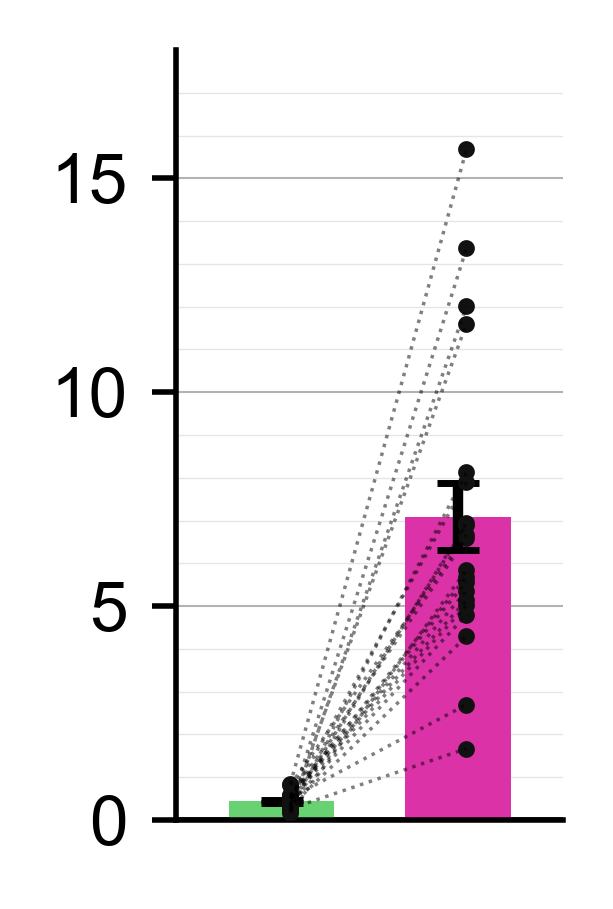

In [30]:
from scipy.stats import sem, ttest_rel, ttest_ind
print(ttest_rel(group_calibration_errors, group_validation_errors))

plt.style.use('default')
color_list = ['#68d171', '#db32a7']
fig, ax = plt.subplots(1,1,figsize=(1,2), dpi=500)

for y in range(18):
    if y % 5 == 0:
        ax.axhline(y=y, color='k', linestyle='-', alpha=0.3, lw=0.3, zorder=0)
    else:
        ax.axhline(y=y, color='k', linestyle='-', alpha=0.1, lw=0.2, zorder=0)
    
ax.bar(np.arange(2), 
       [np.mean(group_calibration_errors), np.mean(group_validation_errors)], 
       yerr=[sem(group_calibration_errors), sem(group_validation_errors)], 
       capsize=3, color=color_list, width=0.6, lw=0.5, zorder=10)

ax.scatter(0*np.ones(len(group_subjects))+0.05, group_calibration_errors, s=2, c='#111111', zorder=50)
ax.scatter(1*np.ones(len(group_subjects))+0.05, group_validation_errors, s=2, c='#111111', zorder=50)

for s in range(len(group_subjects)):
    ax.plot([0+0.05,1+0.05], 
            [group_calibration_errors[s], group_validation_errors[s]], 
            c='k', linestyle=':', lw=0.5, alpha=0.5, zorder=50)
ax.set_xlim(-0.6, 1.6)
ax.set_xticks([])
#ax.set_xticks([0,1])
#ax.set_xticklabels(['', ''])
ax.set_ylim(0.0, 18)
ax.set_yticks([0,5,10,15])
ax.axhline(0, c='k', lw=0.8, zorder=20)
ax.spines[['right', 'top']].set_visible(False)
for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")
plt.subplots_adjust(wspace=0.15)

In [8]:
testable_data

{('sub-003', 'ses-07R', 'task-mcHERDING', 'run-1'): (0,
  0.439710165181016,
  1,
  11.635461878487616,
  1.546219349416633,
  -1.143138491872628,
  1.0411669726367476),
 ('sub-003', 'ses-07R', 'task-mcHERDING', 'run-2'): (0,
  0.40259067363988416,
  1,
  14.394694047176754,
  1.803885670768539,
  -1.3746242225014726,
  1.1680803739967056),
 ('sub-003', 'ses-07R', 'task-mcHERDING', 'run-3'): (0,
  0.4362591657172323,
  1,
  5.9781735691889715,
  0.8046476801458984,
  -0.13567361374567383,
  0.7931270766386467),
 ('sub-003', 'ses-13R', 'task-mcHERDING', 'run-1'): (0,
  0.7538288440740041,
  1,
  6.809315261186104,
  1.0433955298949227,
  -0.5449320475112993,
  0.8897883430343699),
 ('sub-003', 'ses-13R', 'task-mcHERDING', 'run-2'): (0,
  0.6756096619222569,
  1,
  7.265897107799605,
  0.8523721808745279,
  -0.641870462136117,
  0.5608392323705312),
 ('sub-003', 'ses-13R', 'task-mcHERDING', 'run-4'): (0,
  0.4799834936762818,
  1,
  4.192186221759198,
  0.48043332765525293,
  0.170923027

In [9]:
calibation_errors = []
validation_errors = []
pupil_displacements = []
pupil_displacements_x = []
pupil_displacements_y = []
for data in testable_data.items():
    calibation_errors.append(data[1][1])
    validation_errors.append(data[1][3])
    pupil_displacements.append(data[1][4])
    pupil_displacements_x.append(data[1][5])
    pupil_displacements_y.append(data[1][6])

PearsonRResult(statistic=-0.22163543079908257, pvalue=0.019397881537171913)
-4.654114314993392 8.811659039992657


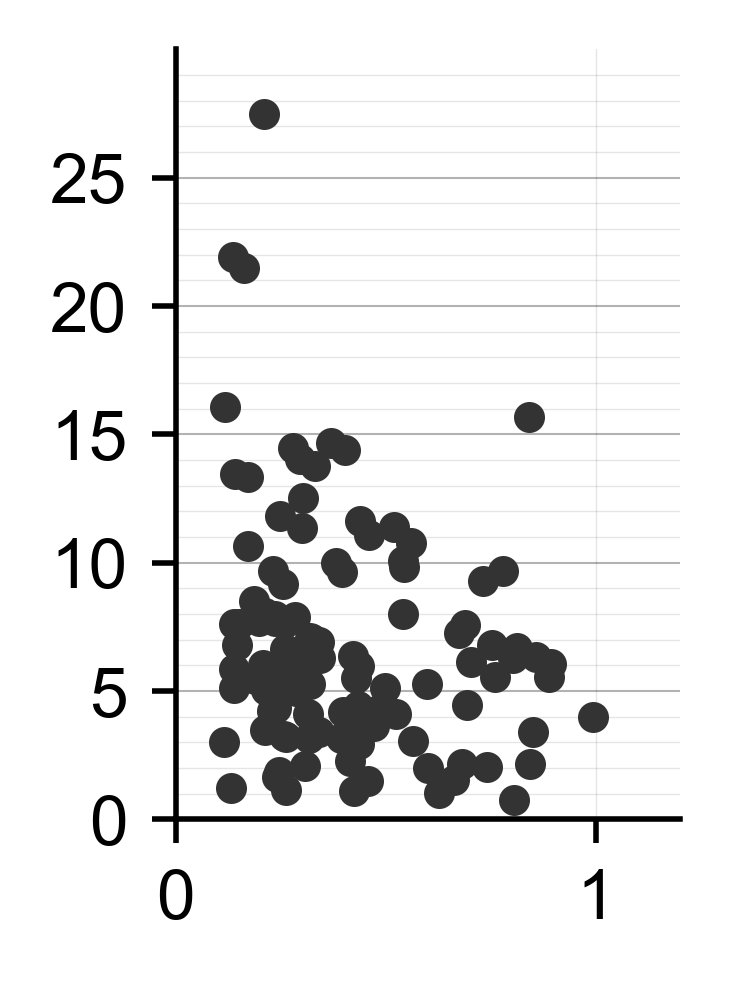

In [29]:
#c55187
from scipy.stats import linregress, pearsonr
x = np.array(calibation_errors)
y = np.array(validation_errors)
print(pearsonr(x,y))

slope, intercept, r, p, stderr = linregress(x, y)
print(slope, intercept)
x_range = np.linspace(np.min(x)-2, np.max(x)+5, 100)

fig, ax = plt.subplots(1,1,figsize=(1.3,2), dpi=500)

for yy in range(30):
    if yy % 5 == 0:
        ax.axhline(y=yy, color='k', linestyle='-', alpha=0.3, lw=0.3, zorder=0)
    else:
        ax.axhline(y=yy, color='k', linestyle='-', alpha=0.1, lw=0.2, zorder=0)
ax.axvline(x=1, color='k', linestyle='-', alpha=0.1, lw=0.2, zorder=0)
    
ax.scatter(x, y, s=12, c='#333333', zorder=100)
#ax.plot(x_range, slope*x_range + intercept, linestyle='--', c='k', lw=1, zorder=100)

ax.spines[['right', 'top']].set_visible(False)
ax.set_ylim(0.0, 30)
ax.set_yticks([0,5,10,15,20,25])
ax.set_xlim(0, 1.2)
ax.set_xticks([0,1])
for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")

PearsonRResult(statistic=0.9022606696816419, pvalue=1.2735213009988792e-41)
5.97849586756387 0.9697989676080478


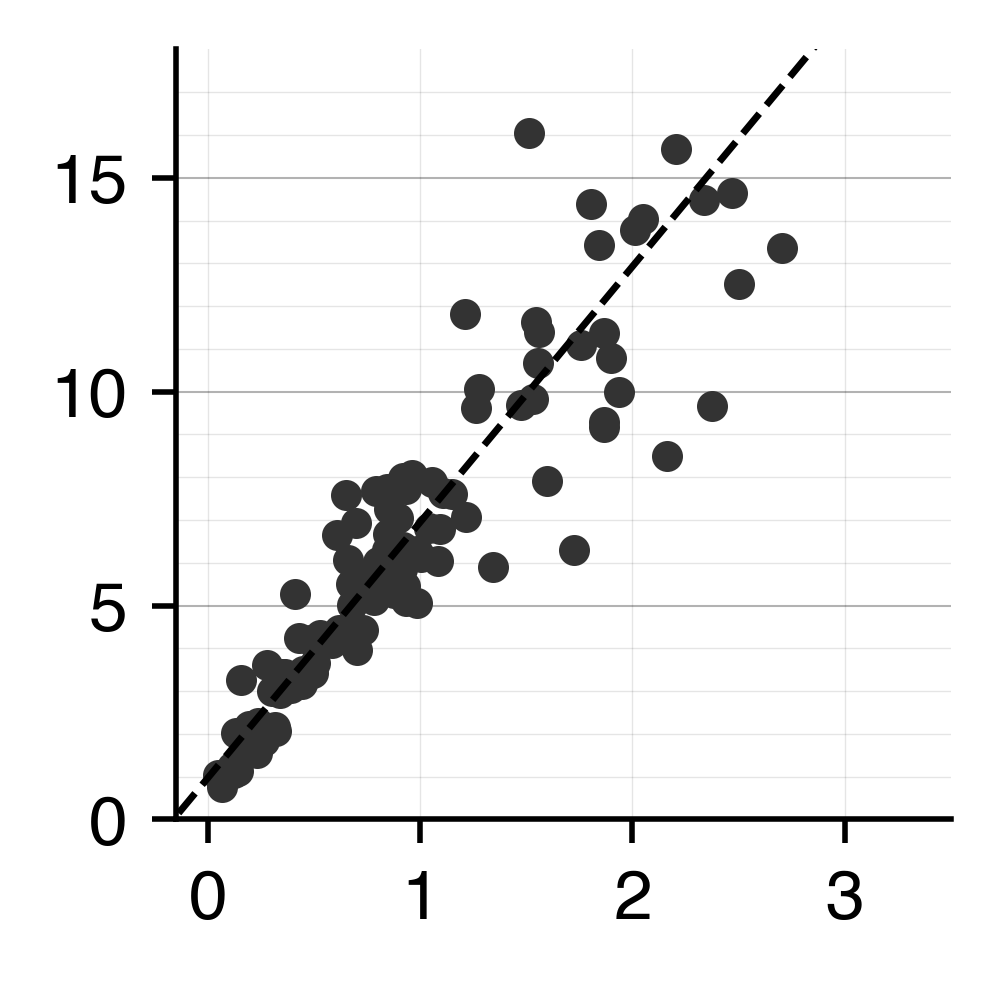

In [11]:
#c55187
from scipy.stats import linregress, pearsonr
x = np.array(pupil_displacements)
y = np.array(validation_errors)
print(pearsonr(x,y))
slope, intercept, r, p, stderr = linregress(x, y)
#p = np.polyfit(np.log(x), y, 1)
# y = p[0] log(x) + p[1]
print(slope, intercept)
#print(p[0]*np.log(0.5) + p[1], p[0]*np.log(1.0) + p[1])
x_range = np.linspace(np.min(x)-2, np.max(x)+5, 100)

fig, ax = plt.subplots(1,1,figsize=(2,2), dpi=500)

for yy in range(18):
    if yy % 5 == 0:
        ax.axhline(y=yy, color='k', linestyle='-', alpha=0.3, lw=0.3, zorder=0)
    else:
        ax.axhline(y=yy, color='k', linestyle='-', alpha=0.1, lw=0.2, zorder=0)
for xx in range(5):
    ax.axvline(x=xx, color='k', linestyle='-', alpha=0.1, lw=0.2, zorder=0)
    
ax.scatter(x, y, s=12, c='#333333', zorder=100)
ax.plot(x_range, slope*x_range + intercept, linestyle='--', c='k', lw=1, zorder=100)

ax.spines[['right', 'top']].set_visible(False)
ax.set_ylim(0.0, 18)
ax.set_yticks([0,5,10,15])
ax.set_xlim(-0.15, 3.5)
ax.set_xticks([0,1,2,3])
for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")

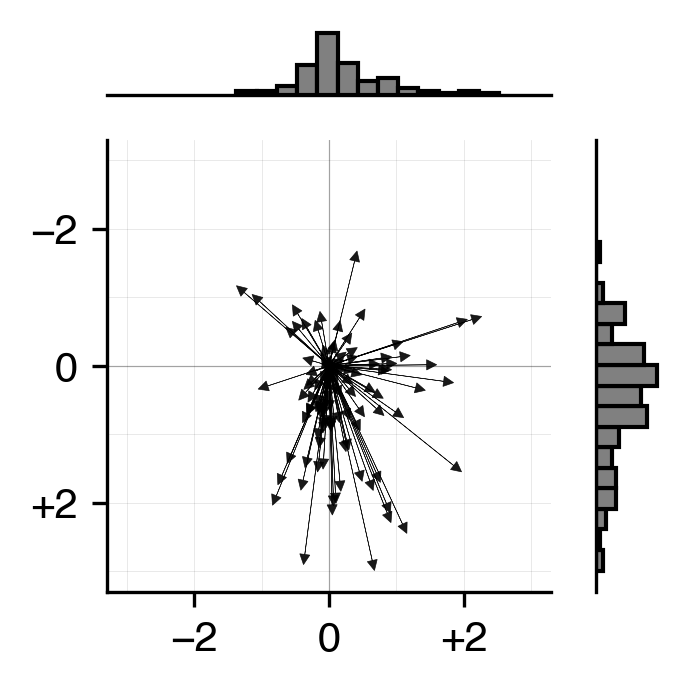

In [86]:
bin_width = 0.3
x_bins = np.arange(min(pupil_displacements_x), max(pupil_displacements_x) + bin_width, bin_width)
y_bins = np.arange(min(pupil_displacements_y), max(pupil_displacements_y) + bin_width, bin_width)


# Create a figure with GridSpec
fig = plt.figure(figsize=(2.4, 2.4), dpi=300)
gs = GridSpec(2, 2, figure=fig, width_ratios=[7, 1], height_ratios=[1, 7])

# Main scatter plot
ax_main = fig.add_subplot(gs[1, 0])
for (dx, dy) in zip(pupil_displacements_x, pupil_displacements_y):
    ax_main.arrow(0, 0, dx, dy, lw=0.15, head_width=0.15, head_length=0.15, 
                  fc='k', ec=None, zorder=100, alpha=0.9, length_includes_head=True)
    #ax_main.scatter(dx, dy, s=10, c='#db32a7', marker='+', zorder=110)
# ax_main.arrow(0, 0, np.mean(pupil_displacements_x), np.mean(pupil_displacements_y),
#               lw=1, head_width=0.2, head_length=0.2, 
#                   fc='r', ec=None, zorder=200, alpha=1.0, length_includes_head=True)

ax_main.axhline(y=0, color='k', linestyle='-', alpha=0.3, lw=0.3, zorder=0)
ax_main.axvline(x=0, color='k', linestyle='-', alpha=0.3, lw=0.3, zorder=0)
ax_main.set_xticks([-2, 0, 2])
ax_main.set_yticks([-2, 0, 2])
ax_main.set_xticklabels(['−2', '0', '+2'])
ax_main.set_yticklabels(['+2', '0', '−2'])

for xx in range(-3, +4):
    ax_main.axvline(x=xx, color='k', linestyle='-', alpha=0.1, lw=0.2, zorder=0)
    ax_main.axhline(y=xx, color='k', linestyle='-', alpha=0.1, lw=0.2, zorder=0)
ax_main.spines[['right', 'top']].set_visible(False)

for tick in ax_main.get_yticklabels():
    tick.set_fontname("Helvetica")
for tick in ax_main.get_xticklabels():
    tick.set_fontname("Helvetica")

# Horizontal histogram
ax_histx = fig.add_subplot(gs[0, 0])
ax_histx.hist(pupil_displacements_x, bins=x_bins, color='gray', edgecolor='black')
ax_histx.spines[['right', 'top', 'left']].set_visible(False)
#ax_histx.axvline(x=0, color='k', linestyle='-', alpha=0.3, lw=0.3, zorder=10)
ax_histx.set_xticks([])
ax_histx.set_yticks([])

# Vertical histogram
ax_histy = fig.add_subplot(gs[1, 1])
ax_histy.hist(pupil_displacements_y, bins=y_bins, orientation='horizontal', color='gray', edgecolor='black')
#ax_histy.axhline(y=0, color='k', linestyle='-', alpha=0.3, lw=0.3, zorder=10)
ax_histy.spines[['right', 'top', 'bottom']].set_visible(False)
ax_histy.set_xticks([])
ax_histy.set_yticks([])

# Align the limits
ax_histx.set_xlim(ax_main.get_xlim())
ax_histy.set_ylim(ax_main.get_ylim())

for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")
    
plt.tight_layout()
plt.show()

In [84]:
from scipy.stats import ttest_1samp
print(ttest_1samp(pupil_displacements_x, 0))
print(ttest_1samp(pupil_displacements_y, 0))

TtestResult(statistic=3.0378633986731756, pvalue=0.002976290401033259, df=110)
TtestResult(statistic=-5.9715203413370475, pvalue=2.9351590913203206e-08, df=110)


In [2]:
import pickle
with open('testable_data_list.pkl', 'rb') as f:
    testable_data = pickle.load(f)

{('sub-003', 'ses-07R', 'task-mcHERDING', 'run-1'): (0,
  0.439710165181016,
  1,
  11.635461878487616,
  1.546219349416633),
 ('sub-003', 'ses-07R', 'task-mcHERDING', 'run-2'): (0,
  0.40259067363988416,
  1,
  14.394694047176754,
  1.803885670768539),
 ('sub-003', 'ses-07R', 'task-mcHERDING', 'run-3'): (0,
  0.4362591657172323,
  1,
  5.9781735691889715,
  0.8046476801458984),
 ('sub-003', 'ses-13R', 'task-mcHERDING', 'run-1'): (0,
  0.7538288440740041,
  1,
  6.809315261186104,
  1.0433955298949227),
 ('sub-003', 'ses-13R', 'task-mcHERDING', 'run-2'): (0,
  0.6756096619222569,
  1,
  7.265897107799605,
  0.8523721808745279),
 ('sub-003', 'ses-13R', 'task-mcHERDING', 'run-4'): (0,
  0.4799834936762818,
  1,
  4.192186221759198,
  0.48043332765525293),
 ('sub-003', 'ses-13R', 'task-mcHERDING', 'run-5'): (0,
  0.28625546575791994,
  1,
  5.016509567140158,
  0.6780543280345879),
 ('sub-004', 'ses-07R', 'task-mcHERDING', 'run-1'): (0,
  0.5420477323798231,
  1,
  7.983210070019476,
  0.